Original paper of autoencoder **Reducing the Dimensionality of Data with Neural Networks**

In [5]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
device = 'gpu' if torch.cuda.is_available() else 'cpu'
transform = transforms.ToTensor() # Needed for tensor transformation

# We'll be using MNIST dataset
train_dataset = datasets.MNIST(
    root='./MNIST_data',
    train=True,
    download=True,
    transform=transform
)

train_loader  = DataLoader(
    dataset=train_dataset,
    batch_size = 16,
    shuffle=True # For training, shuffle always true
)


class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder  = nn.Sequential(
            nn.Linear(784, 1000),
            nn.ReLU(), # Taking ReLU activation
            nn.Linear(1000,500),
            nn.ReLU(),
            nn.Linear(500, 250),
            nn.ReLU(),
            nn.Linear(250,30) # Bottleneck
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(30, 250),
            nn.ReLU(),
            nn.Linear(250, 500),
            nn.ReLU(),
            nn.Linear(500, 1000),
            nn.ReLU(),
            nn.Linear(1000, 784),
            nn.Sigmoid() # Final sigmoid activation function for better prediction
        )
    
    def forward(self,x):
        latent = self.encoder(x)
        reconstructed  = self.decoder(latent)
        return reconstructed # Reconstructed image using autoencoder
    

In [6]:
model = Autoencoder().to(device=device) # Loading model into device
criterion = nn.MSELoss()
optimizer = optim.Adam(params=model.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for images, _ in train_loader:
        images = images.view(images.size(0),-1).to(device) # Flattening image
        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad() # Backpropagation
        loss.backward()
        optimizer.step()
        total_loss +=loss.item()

    avg_loss = total_loss/len(train_loader)
    print(f"Epoch: [{epoch+1}/10] Loss: {avg_loss:.4f}")
print("Complete Training")


Epoch: [1/10] Loss: 0.0313
Epoch: [2/10] Loss: 0.0194
Epoch: [3/10] Loss: 0.0164
Epoch: [4/10] Loss: 0.0141
Epoch: [5/10] Loss: 0.0129
Epoch: [6/10] Loss: 0.0121
Epoch: [7/10] Loss: 0.0115
Epoch: [8/10] Loss: 0.0111
Epoch: [9/10] Loss: 0.0106
Epoch: [10/10] Loss: 0.0103
Complete Training


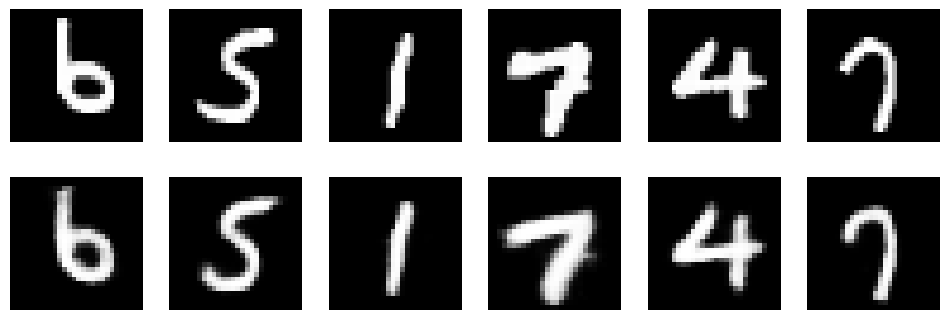

In [7]:
import matplotlib.pyplot as plt
iamges, _ = next(iter(train_loader)) # Getting one batch
images = images.view(images.size(0), -1).to(device)

with torch.no_grad():
    reconstructed = model(images) # Reconstructed image

original = images.cpu().view(-1, 28, 28)
reconstructed = reconstructed.cpu().view(-1, 28, 28)
fig, axes = plt.subplots(2, 6, figsize=(12, 4))

for i in range(6):

    # Original
    axes[0, i].imshow(original[i], cmap='gray')
    axes[0, i].axis('off')

    # Reconstructed
    axes[1, i].imshow(reconstructed[i], cmap='gray')
    axes[1, i].axis('off')

plt.show()